In [1]:
!pip install yfinance -q

[**                     5%                       ]  3 of 55 completed

Fetching data from 2016-02-18 to 2026-02-15...


[*********************100%***********************]  55 of 55 completed


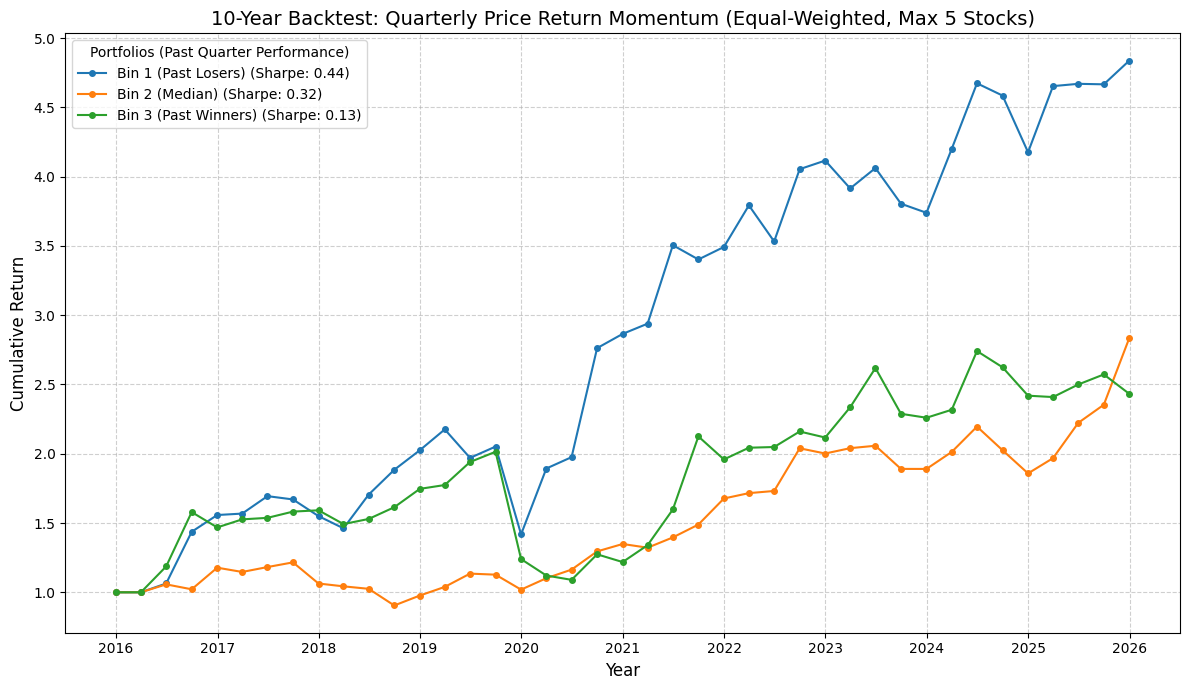


=== Strategy Performance Metrics (Risk-Free Rate: 6%) ===
                        CAGR Ann. Volatility Sharpe Ratio
Bin 1 (Past Losers)   17.08%          25.25%         0.44
Bin 2 (Median)        10.98%          15.46%         0.32
Bin 3 (Past Winners)   9.29%          24.49%         0.13


In [16]:
# 1. Install and Import Required Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import warnings
warnings.filterwarnings('ignore')

# 2. Define Parameters & Stock Universe
tickers = [
    # 17 years streak
    "INDF.JK", "TGKA.JK", "ACES.JK", "UNVR.JK", "ADMF.JK", "ADRO.JK",
    "AKRA.JK", "MTDL.JK", "UNTR.JK", "LSIP.JK", "KLBF.JK", "PANS.JK", "ARNA.JK",
    "ASDM.JK", "ASGR.JK", "ASII.JK", "ITMG.JK", "AUTO.JK", "INTP.JK", "TSPC.JK",
    "CLPI.JK", "SMSM.JK", "BBCA.JK", "BBNI.JK", "BBRI.JK", "AALI.JK", "BDMN.JK",
    "HMSP.JK", "HEXA.JK", "PTBA.JK", "SMGR.JK", "TLKM.JK", "DVLA.JK", "EKAD.JK",
    "TOTO.JK", "TOTL.JK",
    # 16 years streak
    "SCCO.JK", "MKPI.JK",
    # 15 years streak
    "SKLT.JK", "ROTI.JK", "BJBR.JK", "BISI.JK", "ICBP.JK",
    # 13 years streak
    "TRIS.JK", "ELSA.JK", "RDTX.JK", "BJTM.JK",
    # 12 years streak
    "MYOH.JK", "BFIN.JK", "SIDO.JK", "BSSR.JK",
    # 11 years streak
    "CINT.JK", "GEMS.JK", "EPMT.JK",
    # 10 years streak
    "POWR.JK"
]

end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=10*365)
n_bins = 3 # 1 = Lowest Return, 2 = Medium Return, 3 = Highest Return
rf_rate = 0.06 # 6% Annual Risk-Free Rate
periods_per_year = 4 # Quarterly Rebalancing

print(f"Fetching data from {start_date} to {end_date}...")

# 3. Fetch Historical Price Data
price_data_full = yf.download(tickers, start=start_date, end=end_date)

# Check for 'Adj Close' and fallback to 'Close'
if 'Adj Close' in price_data_full.columns.get_level_values(0):
    price_data = price_data_full['Adj Close']
elif 'Close' in price_data_full.columns.get_level_values(0):
    warnings.warn("'Adj Close' not found, using 'Close' prices instead.")
    price_data = price_data_full['Close']
else:
    raise ValueError("Neither 'Adj Close' nor 'Close' prices found.")

# 4. Resample to Quarterly ('QE') and Calculate Returns
quarterly_prices = price_data.resample('QE').last()

# Sorting Factor: Past 1-Quarter Return
past_returns = quarterly_prices.pct_change()

# Target Variable: Next Quarter's Return (Forward Return)
forward_returns = quarterly_prices.pct_change().shift(-1)

# 5. Formulate Bins (Cross-Sectional Sorting, Max 5 Stocks per Bin)
def assign_bins_max5(row):
    # Drop NaNs and sort ascending based on past return
    valid_returns = row.dropna().sort_values()
    n = len(valid_returns)

    res = pd.Series(np.nan, index=row.index)
    if n == 0:
        return res

    # Bin 1: Lowest 5 Past Returns (Losers)
    b1_idx = valid_returns.head(5).index
    res.loc[b1_idx] = 1

    # Bin 3: Highest 5 Past Returns (Winners)
    b3_idx = valid_returns.tail(5).index
    b3_idx = [idx for idx in b3_idx if pd.isna(res.loc[idx])] # Prevent overlap
    res.loc[b3_idx] = 3

    # Bin 2: Middle 5 Past Returns (Closest to Median)
    if n >= 3:
        mid_point = n // 2
        start_idx = max(0, mid_point - 2)
        end_idx = min(n, start_idx + 5)

        b2_idx = valid_returns.iloc[start_idx:end_idx].index
        b2_idx = [idx for idx in b2_idx if pd.isna(res.loc[idx])]
        res.loc[b2_idx[:5]] = 2

    return res

# Apply custom binning at the end of each quarter based on the recent quarter's performance
yield_bins = past_returns.apply(assign_bins_max5, axis=1)

# 6. Backtest the Bins
portfolio_returns = {}

for b in range(1, n_bins + 1):
    is_in_bin = (yield_bins == b)

    # Calculate equal weights for the stocks in the bin safely
    bin_counts = is_in_bin.sum(axis=1)
    weights = np.where(bin_counts > 0, 1.0 / bin_counts, 0)

    # Multiply forward returns by the weights and sum them up for the portfolio return
    port_ret = (forward_returns[is_in_bin] * weights[:, None]).sum(axis=1, skipna=True)

    # Safely handle any quarters where the bin had 0 stocks
    port_ret[bin_counts == 0] = 0.0

    name = f'Bin {b} (Past Winners)' if b == n_bins else f'Bin {b} (Past Losers)' if b == 1 else f'Bin {b} (Median)'
    portfolio_returns[name] = port_ret

# Create DataFrame of portfolio returns and drop the last row (we don't know the future quarter yet)
strategy_returns = pd.DataFrame(portfolio_returns).iloc[:-1]

# Calculate Cumulative Returns
cumulative_returns = (1 + strategy_returns).cumprod()
# Prepend a starting value of 1.0 for charting purposes
base_date = cumulative_returns.index[0] - pd.Timedelta(days=90)
cumulative_returns.loc[base_date] = 1.0
cumulative_returns = cumulative_returns.sort_index()

# 7. Calculate Performance Metrics (CAGR, Volatility, Sharpe)
years = len(strategy_returns) / periods_per_year
cagr = (cumulative_returns.iloc[-1] ** (1 / years)) - 1
ann_volatility = strategy_returns.std() * np.sqrt(periods_per_year)

# Sharpe Ratio Formula: (Return - Risk Free Rate) / Volatility
sharpe_ratio = (cagr - rf_rate) / ann_volatility

# Combine metrics into a readable DataFrame
metrics_df = pd.DataFrame({
    'CAGR': cagr.apply(lambda x: f"{x:.2%}"),
    'Ann. Volatility': ann_volatility.apply(lambda x: f"{x:.2%}"),
    'Sharpe Ratio': sharpe_ratio.apply(lambda x: f"{x:.2f}")
})

# 8. Visualize the Backtest
plt.figure(figsize=(12, 7))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=f"{col} (Sharpe: {sharpe_ratio[col]:.2f})", marker='o', markersize=4)

plt.title('10-Year Backtest: Quarterly Price Return Momentum (Equal-Weighted, Max 5 Stocks)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(title='Portfolios (Past Quarter Performance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Display performance metrics in the console
print("\n=== Strategy Performance Metrics (Risk-Free Rate: 6%) ===")
print(metrics_df)

In [17]:
print("\nStocks in each Bin by Year:")
for year in yield_bins.index:
    print(f"\nYear: {year.year}")
    for b in range(1, n_bins + 1):
        # Get tickers that are in the current bin for the current year
        stocks_in_bin = yield_bins.loc[year][yield_bins.loc[year] == b].index.tolist()
        if stocks_in_bin:
            bin_label = f'Bin {b} (Highest Yield)' if b == n_bins else f'Bin {b}'
            print(f"  {bin_label}: {', '.join(stocks_in_bin)}")
        else:
            bin_label = f'Bin {b} (Highest Yield)' if b == n_bins else f'Bin {b}'
            print(f"  {bin_label}: No stocks in this bin.")


Stocks in each Bin by Year:

Year: 2016
  Bin 1: No stocks in this bin.
  Bin 2: No stocks in this bin.
  Bin 3 (Highest Yield): No stocks in this bin.

Year: 2016
  Bin 1: AALI.JK, ASDM.JK, INTP.JK, LSIP.JK, TGKA.JK
  Bin 2: ASII.JK, CINT.JK, INDF.JK, MTDL.JK, SKLT.JK
  Bin 3 (Highest Yield): ADMF.JK, ADRO.JK, BSSR.JK, ELSA.JK, ITMG.JK

Year: 2016
  Bin 1: ACES.JK, ARNA.JK, ELSA.JK, GEMS.JK, RDTX.JK
  Bin 2: BSSR.JK, ICBP.JK, LSIP.JK, TLKM.JK, TOTO.JK
  Bin 3 (Highest Yield): ADMF.JK, ADRO.JK, BJBR.JK, HEXA.JK, TSPC.JK

Year: 2016
  Bin 1: AUTO.JK, POWR.JK, TOTO.JK, TSPC.JK, UNVR.JK
  Bin 2: BBCA.JK, BBNI.JK, CLPI.JK, EKAD.JK, SIDO.JK
  Bin 3 (Highest Yield): ADRO.JK, BJBR.JK, GEMS.JK, ITMG.JK, RDTX.JK

Year: 2017
  Bin 1: AALI.JK, BJBR.JK, LSIP.JK, RDTX.JK, TGKA.JK
  Bin 2: ADRO.JK, HMSP.JK, KLBF.JK, PANS.JK, TLKM.JK
  Bin 3 (Highest Yield): AUTO.JK, BFIN.JK, BSSR.JK, SCCO.JK, SKLT.JK

Year: 2017
  Bin 1: BSSR.JK, ELSA.JK, PANS.JK, ROTI.JK, SCCO.JK
  Bin 2: ARNA.JK, BBNI.JK, EKAD.JK

Sharpe Ratio for Bin 3 (Highest Yield) (assuming 0% risk-free rate): 0.81

Simulated Portfolio Value for Bin 3 (Highest Yield) starting with 50,000,000 IDR:


,Bin 3 (Highest Yield)
Date,
2016-01-01,5.000000e+07
2026-12-31,4.373895e+08


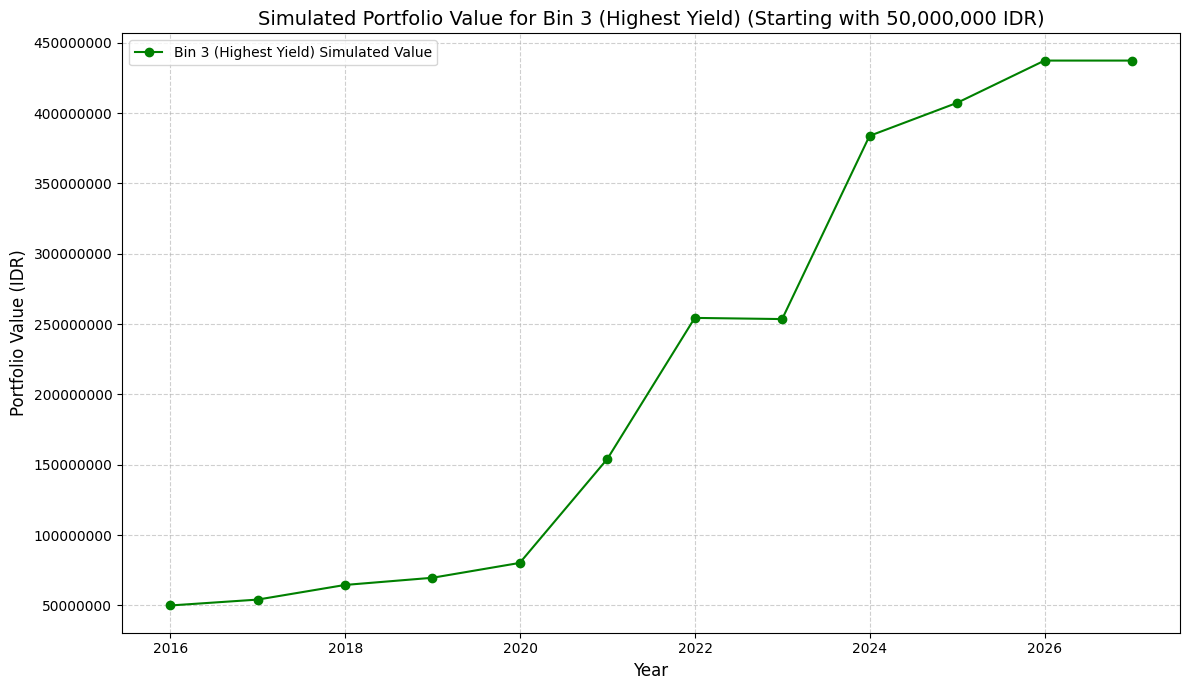

In [15]:
# Calculate Sharpe Ratio for Bin 3 (Highest Yield)
bin3_returns = strategy_returns['Bin 3 (Highest Yield)']
risk_free_rate = 0.0  # Assuming 0% risk-free rate for simplicity, can be adjusted

# For annualized Sharpe, we use the annual returns directly
annualized_mean_return_bin3 = bin3_returns.mean()
annualized_std_dev_bin3 = bin3_returns.std()

# Handle cases where standard deviation might be zero to avoid division by zero
if annualized_std_dev_bin3 == 0:
    sharpe_ratio_bin3 = np.nan # Or define as 0 if mean return is also 0
else:
    sharpe_ratio_bin3 = (annualized_mean_return_bin3 - risk_free_rate) / annualized_std_dev_bin3

print(f"Sharpe Ratio for Bin 3 (Highest Yield) (assuming {risk_free_rate*100:.0f}% risk-free rate): {sharpe_ratio_bin3:.2f}")

# Simulate investment of 10 mil IDR for each stock in Bin 3
# As per the assign_bins_max5 function, there's a maximum of 5 stocks per bin.
# So, an initial investment of 10 million IDR for each of these 5 stocks means 50 million IDR total initial capital for the bin.
initial_investment_per_stock = 10_000_000  # IDR
max_stocks_in_bin = 5
total_initial_investment_bin3 = initial_investment_per_stock * max_stocks_in_bin  # 50,000,000 IDR

# Get cumulative returns for Bin 3
cumulative_returns_bin3 = cumulative_returns['Bin 3 (Highest Yield)']

# Multiply cumulative returns by the total initial investment
simulated_portfolio_value_bin3 = cumulative_returns_bin3 * total_initial_investment_bin3

print(f"\nSimulated Portfolio Value for Bin 3 (Highest Yield) starting with {total_initial_investment_bin3:,.0f} IDR:")
display(simulated_portfolio_value_bin3.iloc[[0, -1]]) # Display only start and end values for brevity

# Plotting the simulated portfolio value
plt.figure(figsize=(12, 7))
plt.plot(simulated_portfolio_value_bin3.index, simulated_portfolio_value_bin3, label='Bin 3 (Highest Yield) Simulated Value', marker='o', color='green')
plt.title(f'Simulated Portfolio Value for Bin 3 (Highest Yield) (Starting with {total_initial_investment_bin3:,.0f} IDR)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Value (IDR)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()